<h1>WWTW CNN — Aerobic Zone / Clarifier Classifier</h1>

This notebook trains a CNN in PyTorch to classify cropped satellite images of WWTW
process units (aerobic zones or clarifiers) into their functional state, using the
dataset produced by `prepare_cnn_dataset.py`.

**Structure:**
1. Imports & config
2. Load dataset (`ImageFolder`) and split into train / validation / test
3. Inspect a batch of images
4. Shared training / evaluation helpers (used by every model below)
5. Hyperparameter tuning summary (architecture + learning hyperparameters)
6. ResNet-18
7. ResNet-50
8. DenseNet-121
9. InceptionNet v3
10. Model comparison
11. Save the trained models

Four backbones are trained and compared: ResNet-18 (baseline), ResNet-50,
DenseNet-121 and InceptionNet v3. Each gets the same treatment — training
curves, a confusion matrix, a per-class report and one-vs-rest ROC/AUC curves
— using a shared set of helper functions so the four sections stay consistent
and easy to compare.

Set `COMPONENT` below to `"aerobic_zone"` or `"clarifier"` depending on which
classifier you're training — everything else adapts automatically based on how
many class folders are found.

**Note on image shape:** aerobic zone crops are rectangular (roughly 2:1,
width:height) rather than square, since that's the actual shape of the aerated
basins. Resizing them to a square would distort the surface texture the model
relies on (the "leopard print" pattern), so this notebook resizes to a fixed
*rectangle* matching that aspect ratio instead. Clarifier crops, being circular
regions, stay closer to square.

In [1]:
# preamble - imports
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 1. Config

Points at the output of `prepare_cnn_dataset.py`. Switch `COMPONENT` to
`"clarifier"` to train that classifier instead — no other changes needed.

`IMG_TARGET_SIZE` is a `(height, width)` pair per component, chosen to match
the real aspect ratio of each crop type rather than forcing a square.

In [2]:
# ------------------------- CONFIG -------------------------

DATASET_ROOT = Path("../cnn_dataset_split")   # adjust if your output folder is elsewhere
COMPONENT = "aerobic_zone"              # "aerobic_zone" or "clarifier"

# (height, width) — aerobic zones are ~2:1 (wide rectangles), clarifiers are
# closer to square since they're circular tank crops. Adjust if your actual
# crop aspect ratios differ noticeably — check a few images if unsure.
IMG_TARGET_SIZE = {
    "aerobic_zone": (112, 224),
    "clarifier": (224, 224),
}[COMPONENT]

BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4     # L2 regularization — helps reduce the train/val gap
EPOCHS = 100
EARLY_STOP_PATIENCE = 10   # stop if val loss hasn't improved for this many epochs
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
SEED = 42

MODEL_SAVE_PATH = Path(f"../models/{COMPONENT}_cnn.pt")

# ------------------------------------------------------------------

data_dir = DATASET_ROOT / COMPONENT
assert data_dir.exists(), f"Dataset folder not found: {data_dir}. Run prepare_cnn_dataset.py first."

torch.manual_seed(SEED)

# 2. Load dataset

`ImageFolder` treats each subfolder name as a class label — this lines up
directly with the `Functional/`, `Suboptimal/`, `Dysfunctional/`, etc. folders
produced by `prepare_cnn_dataset.py`.

Train and eval use different transforms (train gets augmentation), so we build
two `ImageFolder` instances over the same data and split by *indices* to keep
the same images in each split for both.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize(IMG_TARGET_SIZE),   
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # Increased rotation slightly
    # Aggressive color jitter to stop it from memorizing water color or sun glare
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1), 
    # Random blur to simulate different satellite focal qualities
    #transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   
                          std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

# Load explicitly from the predefined split folders
train_ds = datasets.ImageFolder(root=data_dir / "train", transform=train_transform)
val_ds = datasets.ImageFolder(root=data_dir / "val", transform=eval_transform)
test_ds = datasets.ImageFolder(root=data_dir / "test", transform=eval_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Classes found ({num_classes}): {class_names}")

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# DataLoaders remain the same
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1196 | Val: 336 | Test: 189


## Check class balance

Worth looking at before training — if one class dominates, plain accuracy
will be misleading and you may want class weighting in the loss function.

  Dysfunctional  : 561
  Functional     : 482
  Suboptimal     : 153


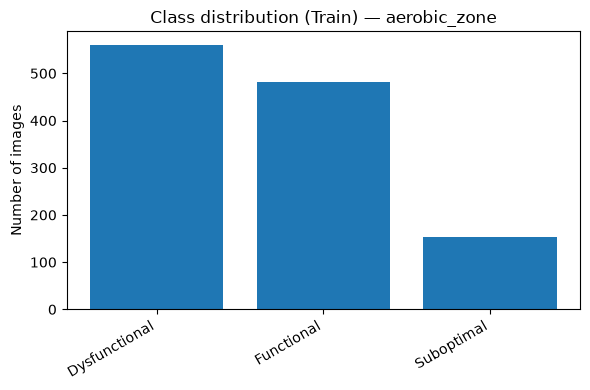

In [4]:
counts = np.bincount([label for _, label in train_ds.samples], minlength=num_classes)
for name, count in zip(class_names, counts):
    print(f"  {name:15s}: {count}")

plt.figure(figsize=(6, 4))
plt.bar(class_names, counts)
plt.ylabel("Number of images")
plt.title(f"Class distribution (Train) — {COMPONENT}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

<h1>Split data</h1>

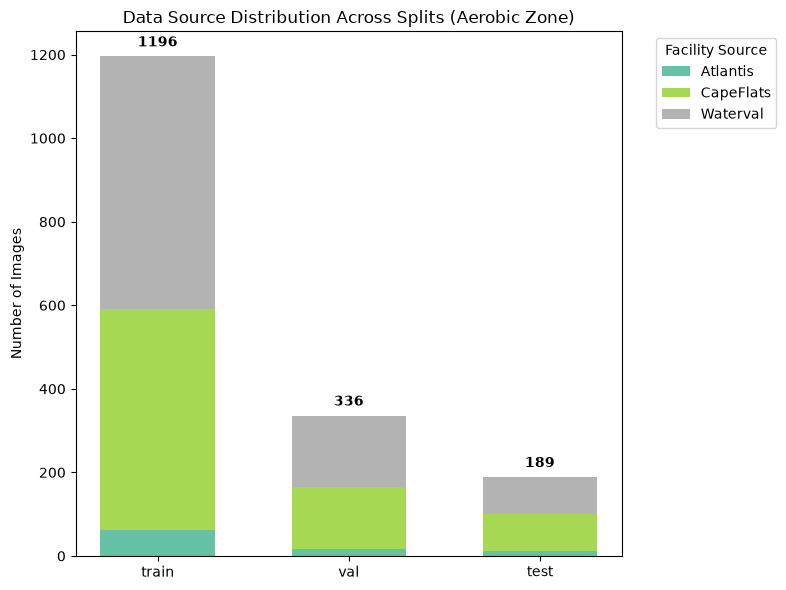

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

data_dir = DATASET_ROOT / COMPONENT 

splits = ['train', 'val', 'test']
split_facility_counts = {split: defaultdict(int) for split in splits}

for split in splits:
    split_dir = data_dir / split
    if not split_dir.exists():
        continue
        
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue
            
        for img_path in class_dir.glob("*.*"):
            facility = img_path.name.split('_')[0]
            split_facility_counts[split][facility] += 1

all_facilities = sorted({
    facility 
    for split_data in split_facility_counts.values() 
    for facility in split_data.keys()
})

plot_data = {facility: [] for facility in all_facilities}

for split in splits:
    for facility in all_facilities:
        plot_data[facility].append(split_facility_counts[split].get(facility, 0))

fig, ax = plt.subplots(figsize=(8, 6))

bottoms = np.zeros(len(splits))

colors = plt.cm.Set2(np.linspace(0, 1, len(all_facilities)))

for idx, facility in enumerate(all_facilities):
    counts = np.array(plot_data[facility])
    ax.bar(splits, counts, label=facility, bottom=bottoms, color=colors[idx], width=0.6)
    bottoms += counts 

ax.set_ylabel('Number of Images')
ax.set_title(f'Data Source Distribution Across Splits ({COMPONENT.replace("_", " ").title()})')
ax.legend(title="Facility Source", bbox_to_anchor=(1.05, 1), loc='upper left')

for i, total in enumerate(bottoms):
    ax.text(i, total + (max(bottoms)*0.02), f'{int(total)}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Inspect a batch

Quick sanity check that images and labels are loading correctly, and that
the rectangular resize looks right (no obvious squishing) before spending
time training.

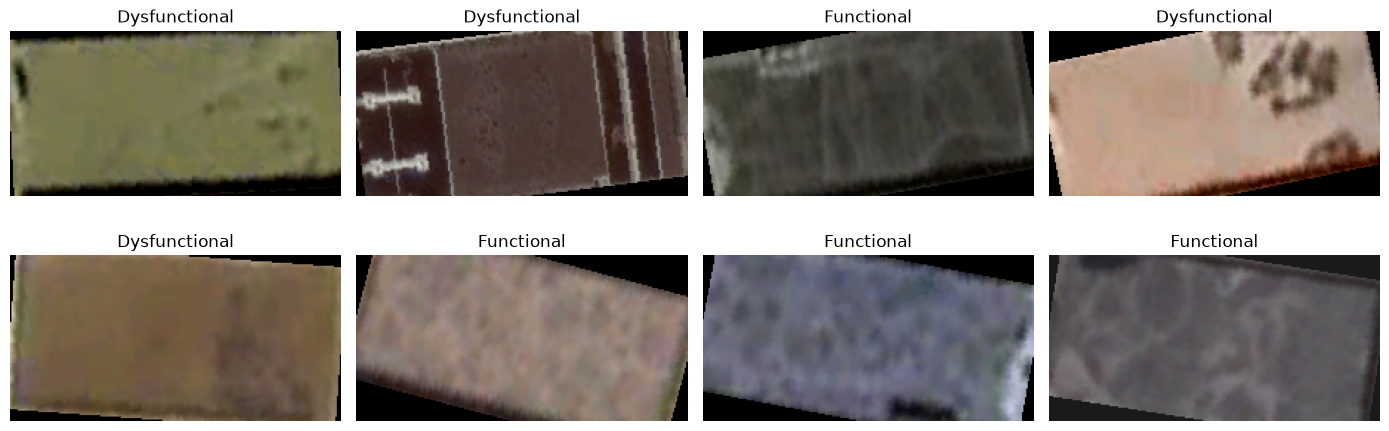

In [6]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, img, label in zip(axes.flatten(), images, labels):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

# 4. Shared training / evaluation helpers

Every backbone below (ResNet-18, ResNet-50, DenseNet-121, InceptionNet v3)
goes through the same pipeline: build a classifier head, train with early
stopping, plot loss/accuracy curves, then evaluate on the test set with a
confusion matrix, a classification report and one-vs-rest ROC/AUC curves.

Pulling that into shared functions here means each model's section below is
just "define the model + hyperparameters, then call these" — the plots stay
identical in style across models so they're easy to compare, and there's one
place to fix things rather than four.

In [7]:
import gc
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# Collects the results (trained model + metrics) for every architecture so
# they can be compared side-by-side in the "Model comparison" section.
results = {}

# Mixed precision roughly halves activation memory and speeds up training on
# GPU, with negligible accuracy impact — a good default when GPU memory is
# tight (e.g. the 7-8 GB cards common on shared/university machines).
USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.float16


def report_gpu_memory(label=""):
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        tag = f" — {label}" if label else ""
        print(f"[GPU memory{tag}] allocated: {alloc:.2f} GB | reserved: {reserved:.2f} GB")


def free_gpu(*names, scope):
    """Deletes the given variable names from `scope` (pass globals()) and
    releases their GPU memory. Needed because optimizers/schedulers hold
    references to GPU tensors (Adam's momentum buffers, in particular) and
    stay alive as notebook globals until explicitly deleted — otherwise each
    architecture's optimizer keeps accumulating in memory across sections."""
    for name in names:
        if name in scope:
            del scope[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    report_gpu_memory("after cleanup")


def build_classifier_head(in_features, hidden_layers, neurons, num_classes):
    """FC classifier head: `hidden_layers` ReLU-activated hidden layers of
    `neurons` units each, ending in a Linear(-> num_classes) layer.

    This mirrors the classifier design swept in the architecture grid search
    (H = number of hidden layers, N = neurons per layer) — see the
    hyperparameter tuning section below. hidden_layers=0 just gives a single
    Linear(in_features, num_classes) layer, which is what the ResNet-18
    baseline uses.
    """
    layers = []
    in_f = in_features
    for _ in range(hidden_layers):
        layers.append(nn.Linear(in_f, neurons))
        layers.append(nn.ReLU(inplace=True))
        in_f = neurons
    layers.append(nn.Linear(in_f, num_classes))
    return nn.Sequential(*layers)


def get_dataloaders(img_size, batch_size):
    """Builds train/val/test ImageFolder datasets + loaders for a given
    image size and batch size. Separate from the global train_loader/etc
    from Section 2 because each architecture below uses its own image size
    (InceptionNet v3 needs 299x299) and its own tuned batch size."""
    train_tf = transforms.Compose([
        transforms.Resize(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
    ])

    tr_ds = datasets.ImageFolder(root=data_dir / "train", transform=train_tf)
    va_ds = datasets.ImageFolder(root=data_dir / "val", transform=eval_tf)
    te_ds = datasets.ImageFolder(root=data_dir / "test", transform=eval_tf)

    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    va_loader = DataLoader(va_ds, batch_size=batch_size, shuffle=False)
    te_loader = DataLoader(te_ds, batch_size=batch_size, shuffle=False)
    return tr_ds, va_ds, te_ds, tr_loader, va_loader, te_loader


def make_class_weights(train_ds_):
    """Inverse-frequency class weights, normalized to sum to num_classes."""
    counts = np.bincount([label for _, label in train_ds_.samples], minlength=num_classes)
    w = 1.0 / torch.tensor(counts, dtype=torch.float32)
    w = w / w.sum() * num_classes
    return w.to(device)


def run_epoch(model, loader, optimizer, criterion, train_mode, is_inception=False,
              accum_steps=1, scaler=None):
    """accum_steps > 1 implements gradient accumulation: the loader uses a
    small "micro batch" that comfortably fits in GPU memory, but gradients
    are accumulated over `accum_steps` micro-batches before each optimizer
    step — so the effective batch size (and the resulting gradient
    statistics) matches the larger tuned batch size without ever holding
    that many samples' activations in memory at once."""
    model.train() if train_mode else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    if train_mode:
        optimizer.zero_grad()

    with torch.set_grad_enabled(train_mode):
        step = 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                if is_inception and train_mode:
                    # Inception's aux classifier gets its own loss term, weighted
                    # down (0.4x), which is the standard way to train it — it
                    # acts as an auxiliary gradient signal earlier in the network.
                    y_hat, aux_hat = model(images)
                    loss = criterion(y_hat, labels) + 0.4 * criterion(aux_hat, labels)
                else:
                    y_hat = model(images)
                    loss = criterion(y_hat, labels)

            if train_mode:
                scaled_loss = loss / accum_steps
                if scaler is not None:
                    scaler.scale(scaled_loss).backward()
                else:
                    scaled_loss.backward()
                if (step + 1) % accum_steps == 0:
                    if scaler is not None:
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        optimizer.step()
                    optimizer.zero_grad()

            total_loss += loss.item() * images.size(0)
            correct += (y_hat.argmax(dim=1) == labels).sum().item()
            total += images.size(0)
            step += 1

        # Flush any leftover accumulated gradients from a final partial group
        if train_mode and total > 0 and step % accum_steps != 0:
            if scaler is not None:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad()

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, scheduler, criterion,
                 epochs, patience, model_name, is_inception=False, accum_steps=1):
    """Training loop with early stopping on validation loss, matching the
    approach used for ResNet-18: track val loss each epoch, keep the
    best-performing weights in memory, stop once val loss hasn't improved
    for `patience` epochs, then restore the best checkpoint."""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    if accum_steps > 1:
        print(f"[{model_name}] Using gradient accumulation: {accum_steps} micro-batches "
              f"per optimizer step (effective batch size ≈ micro_batch x {accum_steps}).")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, optimizer, criterion, True,
                                           is_inception, accum_steps, scaler)
        val_loss, val_acc = run_epoch(model, val_loader, optimizer, criterion, False,
                                       is_inception, accum_steps, scaler)

        if isinstance(scheduler, ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        flag = " *" if improved else ""
        print(f"[{model_name}] Epoch {epoch:3d}/{epochs} | LR: {current_lr:.2e} | "
              f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.3f}{flag}")

        if epochs_no_improve >= patience:
            print(f"\n[{model_name}] No val loss improvement for {patience} epochs — stopping early at epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    print(f"\n[{model_name}] Restored best checkpoint (val loss = {best_val_loss:.4f})")
    return history


def plot_training_curves(history, model_name):
    best_epoch = int(np.argmin(history["val_loss"])) + 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].axvline(best_epoch - 1, color="gray", linestyle="--", linewidth=1, label="restored checkpoint")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].axvline(best_epoch - 1, color="gray", linestyle="--", linewidth=1)
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def collect_predictions(model, loader):
    """Runs the test set through the model once, returning predicted
    labels, true labels and full class-probability vectors (the last one
    is needed for the ROC/AUC curves)."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            y_hat = model(images)
            probs = torch.softmax(y_hat, dim=1).cpu().numpy()
            all_preds.extend(probs.argmax(axis=1))
            all_labels.extend(labels.numpy())
            all_probs.append(probs)
    return np.array(all_preds), np.array(all_labels), np.concatenate(all_probs, axis=0)


def plot_confusion_and_report(all_labels, all_preds, class_names, model_name):
    test_acc = np.mean(all_preds == all_labels)
    print(f"[{model_name}] Test accuracy: {test_acc:.3f}")

    cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=30)
    plt.title(f"Confusion matrix — {model_name} ({COMPONENT} test set)")
    plt.tight_layout()
    plt.show()

    print(classification_report(
        all_labels,
        all_preds,
        labels=range(len(class_names)),
        target_names=class_names,
        digits=3,
        zero_division=0
    ))
    return test_acc


def plot_roc_auc(all_labels, all_probs, class_names, num_classes, model_name):
    y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))

    plt.figure(figsize=(7, 6))
    roc_aucs = {}
    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
        auc = roc_auc_score(y_true_bin[:, i], all_probs[:, i])
        roc_aucs[name] = auc
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance (AUC = 0.500)")
    plt.xlabel("1 - Specificity (False Positive Rate)")
    plt.ylabel("Sensitivity (True Positive Rate)")
    plt.title(f"ROC curves — {model_name} ({COMPONENT} test set)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("AUC (area under ROC curve) per class:")
    for name, auc in roc_aucs.items():
        print(f"  {name:15s}: {auc:.3f}")
    print(f"\nMean AUC: {np.mean(list(roc_aucs.values())):.3f}")
    return roc_aucs


def evaluate_and_record(model, test_loader, model_name, history, img_size, hidden_layers, neurons):
    """Runs the full evaluation block (confusion matrix, report, ROC/AUC)
    for one trained model and stores everything in `results` for the
    comparison section at the end."""
    preds, labels_, probs = collect_predictions(model, test_loader)
    test_acc = plot_confusion_and_report(labels_, preds, class_names, model_name)
    roc_aucs = plot_roc_auc(labels_, probs, class_names, num_classes, model_name)

    # Move the finished model to CPU before storing it. Keeping every
    # trained model resident on the GPU is what causes later sections to run
    # out of memory — we only need the weights (for saving / comparison), not
    # for the model to stay on GPU. It can be moved back with .to(device)
    # for any further inference.
    model_cpu = model.to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    results[model_name] = dict(
        model=model_cpu, history=history, test_acc=test_acc,
        mean_auc=float(np.mean(list(roc_aucs.values()))),
        img_size=img_size, hidden_layers=hidden_layers, neurons=neurons,
    )
    return test_acc, roc_aucs


# 5. Hyperparameter tuning summary

The classifier head design and learning hyperparameters used for ResNet-50,
DenseNet-121 and InceptionNet v3 below come from a two-stage tuning process
(documented in the thesis' Hyperparameter Tuning chapter), rather than being
picked by hand:

**Architecture (H, N) — grid search.** With the FC layers stripped off each
pretrained backbone, a classifier head is attached made of `H` ReLU-activated
hidden layers of `N` neurons each. A grid search over `H ∈ {2, 3}` and
`N ∈ {1024, 2048}` (with a mid-range learning rate, batch size and unfreezing
depth held fixed) picks the combination with the lowest training loss and
highest validation accuracy for each backbone — more complex heads
(`H=3, N=2048`) tended to overfit fastest, especially for VGG-16.

**Learning hyperparameters — Bayesian optimization.** For the winning
architecture, the learning rate, Adam's β1 momentum term, the step-decay
frequency `Es` (learning rate ×0.1 every `Es` epochs) and the batch size are
then tuned with Bayesian optimization (20 trials/model, via the `Ax`
library): a Gaussian-process surrogate model is fit to the trials seen so
far, and each new trial is chosen to maximize expected improvement over the
best validation accuracy found. Notably the optimizer found near-zero β1
values worked best for DenseNet-121 and InceptionNet v3, versus the usual
default of 0.9.

The tables below are the results of that process, restricted to the four
backbones trained in this notebook (ResNet-18 wasn't part of the original
sweep, so it keeps its own hand-set hyperparameters).

In [8]:
import pandas as pd

architecture_grid_search = pd.DataFrame([
    {"model": "ResNet-50",       "hidden_layers (H)": 3, "neurons (N)": 1024, "val_accuracy_%": 97.37},
    {"model": "DenseNet-121",    "hidden_layers (H)": 3, "neurons (N)": 2048, "val_accuracy_%": 96.05},
    {"model": "InceptionNet v3", "hidden_layers (H)": 3, "neurons (N)": 2048, "val_accuracy_%": 97.70},
]).set_index("model")

bayesian_opt_results = pd.DataFrame([
    {"model": "ResNet-50",       "learning_rate": 2.68014042e-05, "beta1": 0.1788129,   "step_size_Es": 34, "batch_size": 121},
    {"model": "DenseNet-121",    "learning_rate": 2.74235159e-04, "beta1": 4.149011e-17, "step_size_Es": 7,  "batch_size": 14},
    {"model": "InceptionNet v3", "learning_rate": 1.42756669e-04, "beta1": 5.190841e-17, "step_size_Es": 21, "batch_size": 17},
]).set_index("model")

print("Architecture grid search (best H, N per model):")
display(architecture_grid_search)
print("\nBayesian-optimized learning hyperparameters:")
display(bayesian_opt_results)

# Bundles everything each model's section below needs to build its head,
# optimizer and dataloaders. img_size defaults to the notebook's configured
# IMG_TARGET_SIZE except for InceptionNet v3, which requires larger inputs
# (it downsamples aggressively and expects ~299x299).
ARCH_HYPERPARAMS = {
    "resnet50": dict(
        hidden_layers=3, neurons=1024,
        lr=2.68014042e-05, beta1=0.1788129, step_size=34, batch_size=121,
        img_size=IMG_TARGET_SIZE,
    ),
    "densenet121": dict(
        hidden_layers=3, neurons=2048,
        lr=2.74235159e-04, beta1=4.149011e-17, step_size=7, batch_size=14,
        img_size=IMG_TARGET_SIZE,
    ),
    "inception_v3": dict(
        hidden_layers=3, neurons=2048,
        lr=1.42756669e-04, beta1=5.190841e-17, step_size=21, batch_size=17,
        img_size=(299, 299),
    ),
}

# beta2 (decay rate for the squared-gradient average) is held fixed at 0.9
# for all models, per the tuning setup.
ADAM_BETA2 = 0.9

# Upper bound on the *actual* per-step batch size used on the GPU. Some of
# the tuned batch sizes above (e.g. 121 for ResNet-50) are too large to fit
# a deeper model's activations in memory alongside everything else — the
# training loop uses gradient accumulation to still reach the tuned
# effective batch size without needing that many samples in memory at once.
# Lower this (e.g. to 8) if you still see CUDA out-of-memory errors.
MICRO_BATCH_CAP = 4


Architecture grid search (best H, N per model):


,hidden_layers (H),neurons (N),val_accuracy_%
model,,,
ResNet-50,3,1024,97.37
DenseNet-121,3,2048,96.05
InceptionNet v3,3,2048,97.70



Bayesian-optimized learning hyperparameters:


,learning_rate,beta1,step_size_Es,batch_size
model,,,,
ResNet-50,0.000027,1.788129e-01,34,121
DenseNet-121,0.000274,4.149011e-17,7,14
InceptionNet v3,0.000143,5.190841e-17,21,17


# 6. ResNet-18 (baseline)

In [9]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet18)
# ---------------------------------------------------------
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)


Applying class weights to loss function:
  Dysfunctional  : 0.515
  Functional     : 0.599
  Suboptimal     : 1.887


## Train, then plot training curves

The vertical line marks the epoch that was restored (lowest validation
loss). Everything past that point is where the model was starting to
overfit.

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 1.0618 acc 0.575 | val loss 1.4920 acc 0.705 *
[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.8164 acc 0.660 | val loss 0.7583 acc 0.661 *
[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.6902 acc 0.707 | val loss 1.2699 acc 0.557
[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.6074 acc 0.761 | val loss 0.5501 acc 0.807 *
[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.6185 acc 0.745 | val loss 1.0189 acc 0.625
[ResNet-18] Epoch   6/100 | LR: 5.00e-04 | train loss 0.6765 acc 0.747 | val loss 0.6480 acc 0.747
[ResNet-18] Epoch   7/100 | LR: 5.00e-04 | train loss 0.5651 acc 0.753 | val loss 0.5120 acc 0.792 *
[ResNet-18] Epoch   8/100 | LR: 5.00e-04 | train loss 0.5751 acc 0.776 | val loss 0.6120 acc 0.747
[ResNet-18] Epoch   9/100 | LR: 5.00e-04 | train loss 0.5233 acc 0.807 | val loss 0.5414 acc 0.792
[ResNet-18] Epoch  10/100 | LR: 5.00e-04 | train loss 0.5363 acc 0.786 | val loss 0.6310 acc 0.756
[R

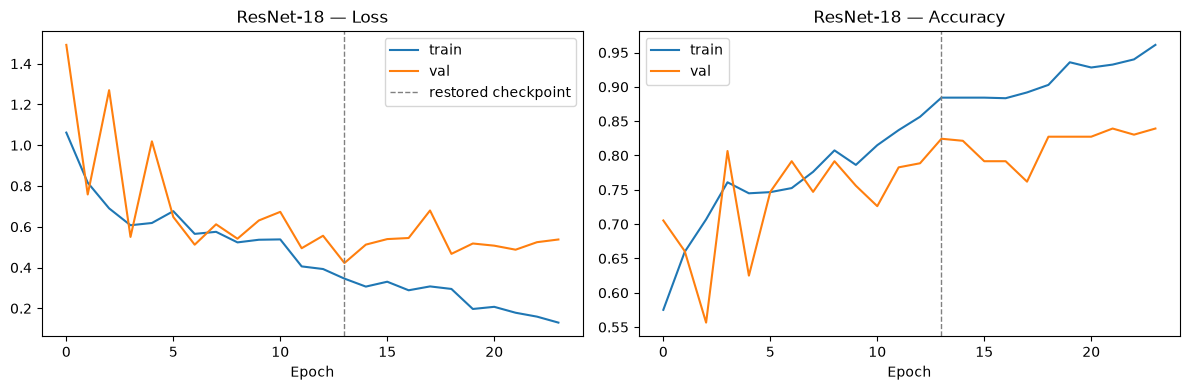

In [10]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")


## Evaluate on the test set

Confusion matrix, per-class precision/recall/F1, and one-vs-rest ROC/AUC
curves — using the restored best checkpoint rather than whichever epoch
training happened to stop on.

[ResNet-18] Test accuracy: 0.757


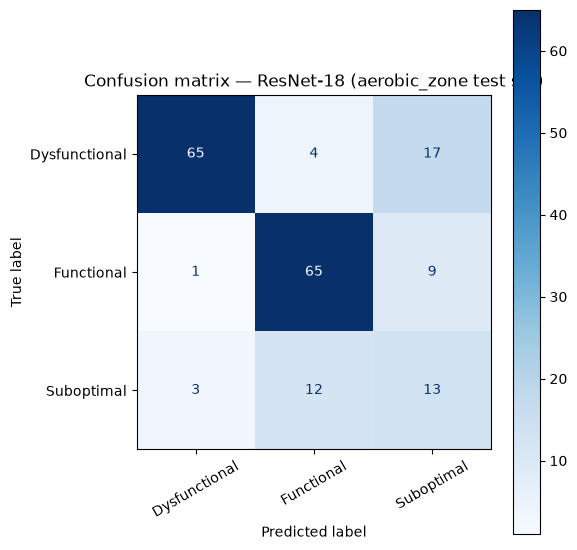

               precision    recall  f1-score   support

Dysfunctional      0.942     0.756     0.839        86
   Functional      0.802     0.867     0.833        75
   Suboptimal      0.333     0.464     0.388        28

     accuracy                          0.757       189
    macro avg      0.693     0.696     0.687       189
 weighted avg      0.796     0.757     0.770       189



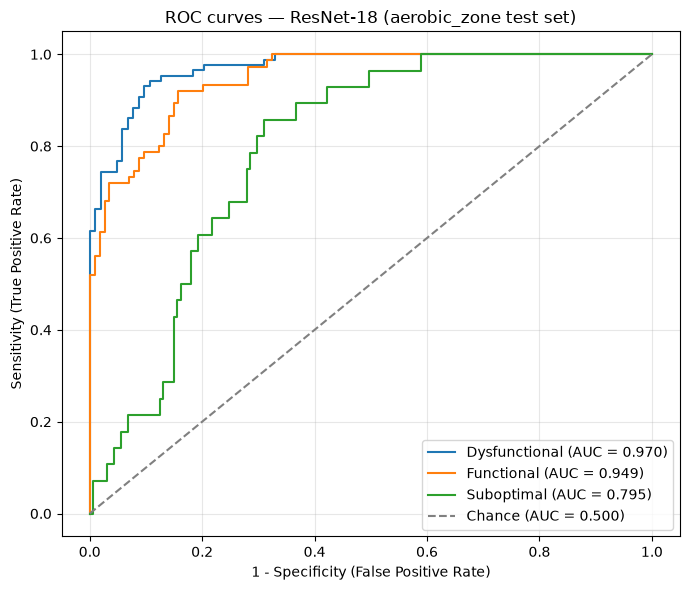

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.970
  Functional     : 0.949
  Suboptimal     : 0.795

Mean AUC: 0.905


(np.float64(0.7566137566137566),
 {'Dysfunctional': 0.9704222172047865,
  'Functional': 0.9485380116959065,
  'Suboptimal': 0.7954747116237799})

In [11]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)


### Free GPU memory before the next model

`optimizer_resnet18` and `scheduler_resnet18` hold references to GPU tensors
(Adam keeps two extra momentum buffers per parameter) and, being notebook
globals, they'd otherwise stay resident for the rest of the session — that's
what was causing later sections to run out of memory. `model_resnet18` was
already moved to CPU inside `evaluate_and_record`, so it's safe to drop the
rest here.

In [12]:
free_gpu("optimizer_resnet18", "scheduler_resnet18", "criterion_resnet18", scope=globals())


[GPU memory — after cleanup] allocated: 0.07 GB | reserved: 0.07 GB


# 7. ResNet-50

In [13]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch_resnet50 = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps_resnet50 = max(1, round(cfg["batch_size"] / micro_batch_resnet50))
print(f"ResNet-50: micro batch = {micro_batch_resnet50}, accumulation steps = {accum_steps_resnet50} "
      f"(effective batch size ≈ {micro_batch_resnet50 * accum_steps_resnet50}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_resnet50, val_ds_resnet50, test_ds_resnet50, train_loader_resnet50, val_loader_resnet50, test_loader_resnet50 = \
    get_dataloaders(cfg["img_size"], micro_batch_resnet50)

class_weights_resnet50 = make_class_weights(train_ds_resnet50)


ResNet-50: micro batch = 4, accumulation steps = 30 (effective batch size ≈ 120, tuned value = 121)


In [14]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model_resnet50.fc.in_features
model_resnet50.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model_resnet50 = model_resnet50.to(device)

criterion_resnet50 = nn.CrossEntropyLoss(weight=class_weights_resnet50)
optimizer_resnet50 = optim.Adam(
    model_resnet50.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler_resnet50 = StepLR(optimizer_resnet50, step_size=cfg["step_size"], gamma=0.1)


## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 30 micro-batches per optimizer step (effective batch size ≈ micro_batch x 30).
[ResNet-50] Epoch   1/100 | LR: 2.68e-05 | train loss 1.0924 acc 0.531 | val loss 1.0747 acc 0.548 *
[ResNet-50] Epoch   2/100 | LR: 2.68e-05 | train loss 1.0778 acc 0.605 | val loss 1.0480 acc 0.631 *
[ResNet-50] Epoch   3/100 | LR: 2.68e-05 | train loss 1.0460 acc 0.628 | val loss 0.9880 acc 0.676 *
[ResNet-50] Epoch   4/100 | LR: 2.68e-05 | train loss 1.0040 acc 0.653 | val loss 0.9412 acc 0.696 *
[ResNet-50] Epoch   5/100 | LR: 2.68e-05 | train loss 0.9493 acc 0.663 | val loss 0.8937 acc 0.714 *
[ResNet-50] Epoch   6/100 | LR: 2.68e-05 | train loss 0.9083 acc 0.678 | val loss 0.8623 acc 0.723 *
[ResNet-50] Epoch   7/100 | LR: 2.68e-05 | train loss 0.8763 acc 0.692 | val loss 0.7902 acc 0.738 *
[ResNet-50] Epoch   8/100 | LR: 2.68e-05 | train loss 0.8798 acc 0.691 | val loss 0.8722 acc 0.735
[ResNet-50] Epoch   9/100 | LR: 2.68e-05 | train loss 0.8453 acc 0.707 | v

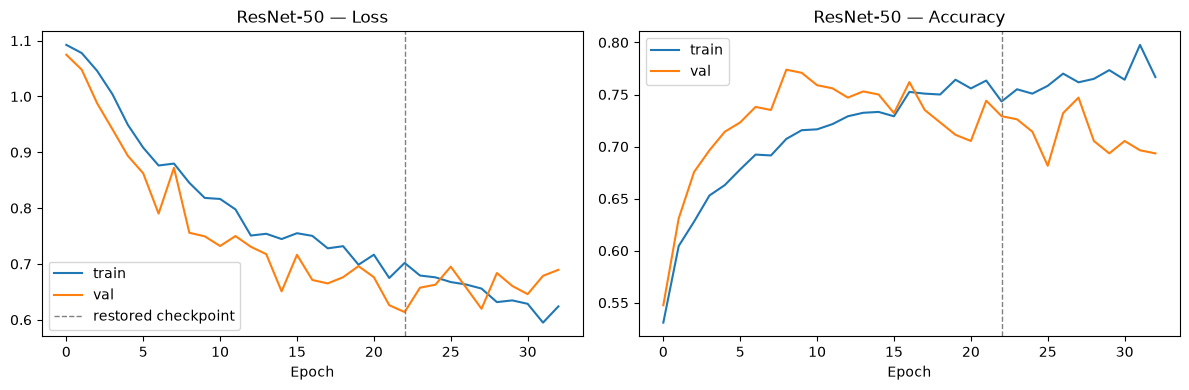

In [15]:
history_resnet50 = train_model(
    model_resnet50, train_loader_resnet50, val_loader_resnet50, optimizer_resnet50, scheduler_resnet50,
    criterion_resnet50, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps_resnet50,
)
plot_training_curves(history_resnet50, "ResNet-50")


## Evaluate on the test set

Confusion matrix, per-class precision/recall/F1, and one-vs-rest ROC/AUC
curves — using the restored best checkpoint.

[ResNet-50] Test accuracy: 0.688


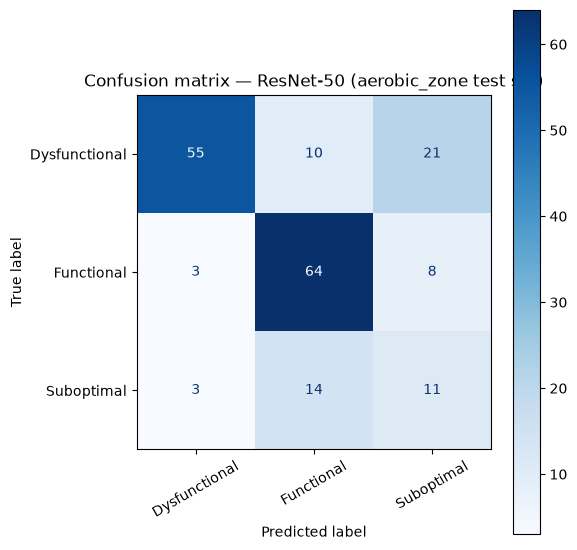

               precision    recall  f1-score   support

Dysfunctional      0.902     0.640     0.748        86
   Functional      0.727     0.853     0.785        75
   Suboptimal      0.275     0.393     0.324        28

     accuracy                          0.688       189
    macro avg      0.635     0.629     0.619       189
 weighted avg      0.740     0.688     0.700       189



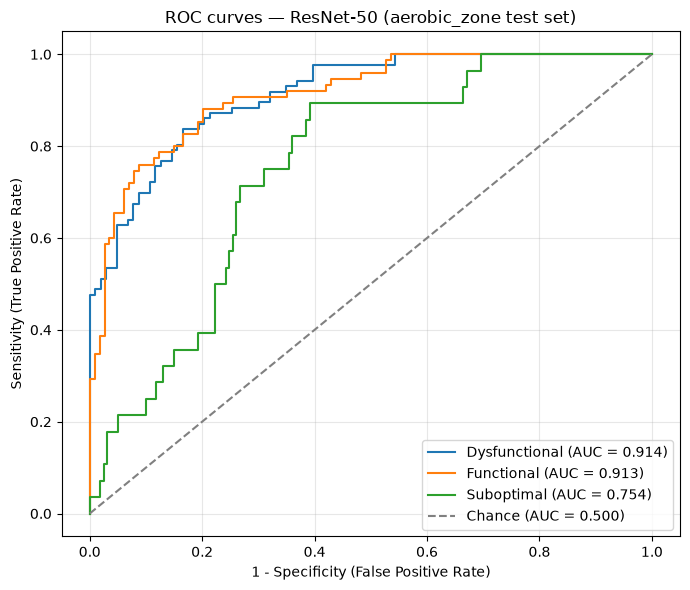

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.914
  Functional     : 0.913
  Suboptimal     : 0.754

Mean AUC: 0.860


(np.float64(0.6878306878306878),
 {'Dysfunctional': 0.9138631745314969,
  'Functional': 0.9129824561403509,
  'Suboptimal': 0.754214729370009})

In [16]:
evaluate_and_record(
    model_resnet50, test_loader_resnet50, "ResNet-50", history_resnet50,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)


### Free GPU memory before the next model

Same reasoning as after ResNet-18 — `optimizer_resnet50` and `scheduler_resnet50`
hold GPU-resident state that would otherwise accumulate across every
remaining section.

In [17]:
free_gpu("optimizer_resnet50", "scheduler_resnet50", "criterion_resnet50", scope=globals())


[GPU memory — after cleanup] allocated: 0.07 GB | reserved: 0.07 GB


# 8. DenseNet-121

In [18]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch_densenet121 = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps_densenet121 = max(1, round(cfg["batch_size"] / micro_batch_densenet121))
print(f"DenseNet-121: micro batch = {micro_batch_densenet121}, accumulation steps = {accum_steps_densenet121} "
      f"(effective batch size ≈ {micro_batch_densenet121 * accum_steps_densenet121}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_densenet121, val_ds_densenet121, test_ds_densenet121, train_loader_densenet121, val_loader_densenet121, test_loader_densenet121 = \
    get_dataloaders(cfg["img_size"], micro_batch_densenet121)

class_weights_densenet121 = make_class_weights(train_ds_densenet121)


DenseNet-121: micro batch = 4, accumulation steps = 4 (effective batch size ≈ 16, tuned value = 14)


In [19]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model_densenet121 = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model_densenet121.classifier.in_features
model_densenet121.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model_densenet121 = model_densenet121.to(device)

criterion_densenet121 = nn.CrossEntropyLoss(weight=class_weights_densenet121)
optimizer_densenet121 = optim.Adam(
    model_densenet121.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler_densenet121 = StepLR(optimizer_densenet121, step_size=cfg["step_size"], gamma=0.1)


## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 4 micro-batches per optimizer step (effective batch size ≈ micro_batch x 4).
[DenseNet-121] Epoch   1/100 | LR: 2.74e-04 | train loss 0.9859 acc 0.646 | val loss 0.7936 acc 0.690 *
[DenseNet-121] Epoch   2/100 | LR: 2.74e-04 | train loss 0.8989 acc 0.704 | val loss 0.7689 acc 0.711 *
[DenseNet-121] Epoch   3/100 | LR: 2.74e-04 | train loss 0.8672 acc 0.696 | val loss 0.5864 acc 0.789 *
[DenseNet-121] Epoch   4/100 | LR: 2.74e-04 | train loss 0.8363 acc 0.706 | val loss 0.4956 acc 0.783 *
[DenseNet-121] Epoch   5/100 | LR: 2.74e-04 | train loss 0.8053 acc 0.731 | val loss 0.6343 acc 0.771
[DenseNet-121] Epoch   6/100 | LR: 2.74e-04 | train loss 0.8008 acc 0.708 | val loss 0.5786 acc 0.768
[DenseNet-121] Epoch   7/100 | LR: 2.74e-05 | train loss 0.7426 acc 0.746 | val loss 0.6817 acc 0.741
[DenseNet-121] Epoch   8/100 | LR: 2.74e-05 | train loss 0.6563 acc 0.740 | val loss 0.5098 acc 0.812
[DenseNet-121] Epoch   9/100 | LR: 2.74e-05 | train los

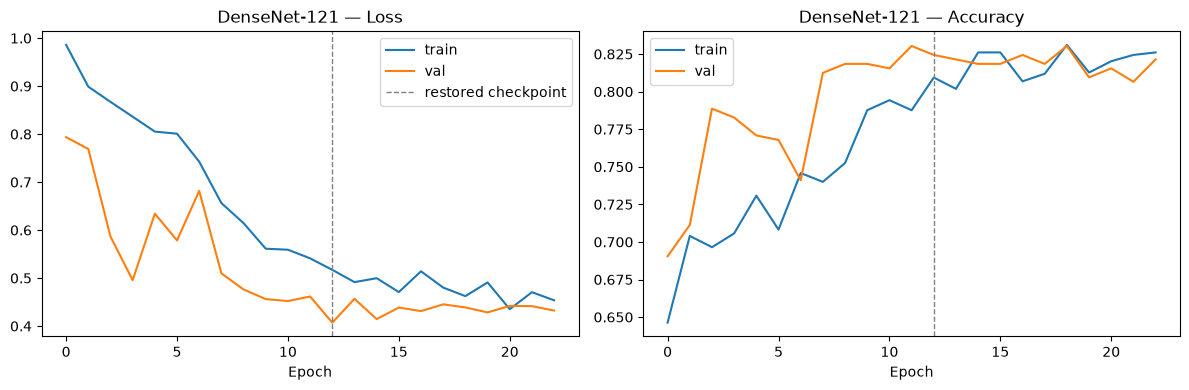

In [20]:
history_densenet121 = train_model(
    model_densenet121, train_loader_densenet121, val_loader_densenet121, optimizer_densenet121, scheduler_densenet121,
    criterion_densenet121, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps_densenet121,
)
plot_training_curves(history_densenet121, "DenseNet-121")


## Evaluate on the test set

Confusion matrix, per-class precision/recall/F1, and one-vs-rest ROC/AUC
curves — using the restored best checkpoint.

[DenseNet-121] Test accuracy: 0.746


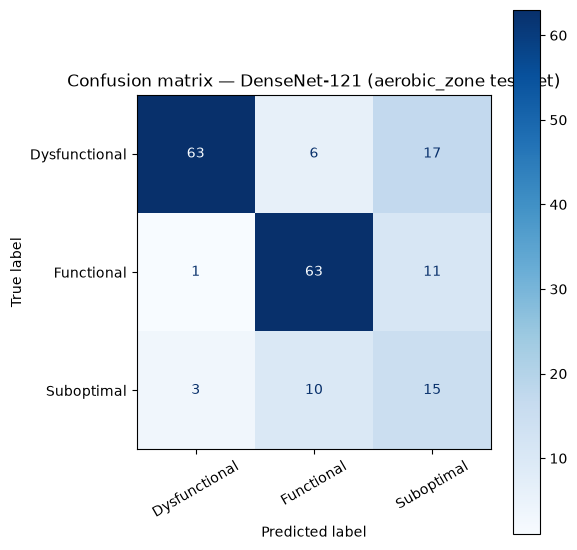

               precision    recall  f1-score   support

Dysfunctional      0.940     0.733     0.824        86
   Functional      0.797     0.840     0.818        75
   Suboptimal      0.349     0.536     0.423        28

     accuracy                          0.746       189
    macro avg      0.696     0.703     0.688       189
 weighted avg      0.796     0.746     0.762       189



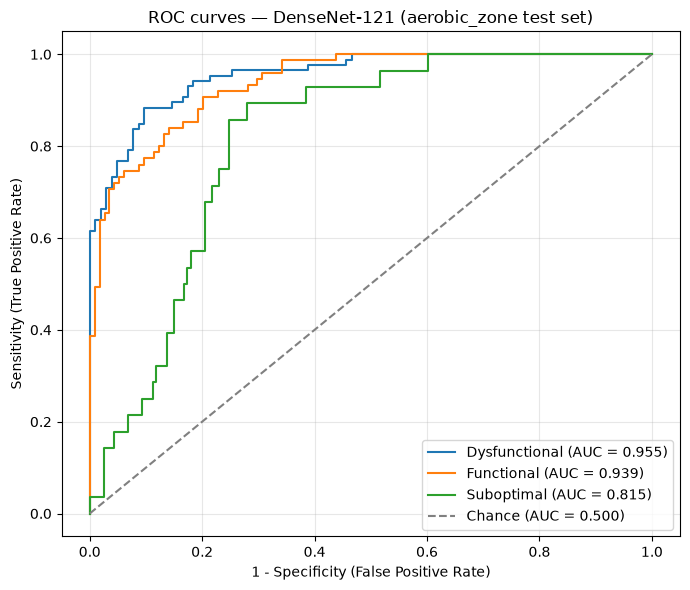

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.955
  Functional     : 0.939
  Suboptimal     : 0.815

Mean AUC: 0.903


(np.float64(0.746031746031746),
 {'Dysfunctional': 0.9552946489049448,
  'Functional': 0.9385964912280701,
  'Suboptimal': 0.8145519077196096})

In [21]:
evaluate_and_record(
    model_densenet121, test_loader_densenet121, "DenseNet-121", history_densenet121,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)


### Free GPU memory before the next model

Same reasoning as after ResNet-18 — `optimizer_densenet121` and `scheduler_densenet121`
hold GPU-resident state that would otherwise accumulate across every
remaining section.

In [22]:
free_gpu("optimizer_densenet121", "scheduler_densenet121", "criterion_densenet121", scope=globals())


[GPU memory — after cleanup] allocated: 0.07 GB | reserved: 0.07 GB


# 9. InceptionNet v3

In [23]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch_inception_v3 = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps_inception_v3 = max(1, round(cfg["batch_size"] / micro_batch_inception_v3))
print(f"InceptionNet v3: micro batch = {micro_batch_inception_v3}, accumulation steps = {accum_steps_inception_v3} "
      f"(effective batch size ≈ {micro_batch_inception_v3 * accum_steps_inception_v3}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_inception_v3, val_ds_inception_v3, test_ds_inception_v3, train_loader_inception_v3, val_loader_inception_v3, test_loader_inception_v3 = \
    get_dataloaders(cfg["img_size"], micro_batch_inception_v3)

class_weights_inception_v3 = make_class_weights(train_ds_inception_v3)


InceptionNet v3: micro batch = 4, accumulation steps = 4 (effective batch size ≈ 16, tuned value = 17)


In [24]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model_inception_v3 = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model_inception_v3.fc.in_features
model_inception_v3.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch) also
# needs its output layer resized to our number of classes.
in_f_aux = model_inception_v3.AuxLogits.fc.in_features
model_inception_v3.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model_inception_v3 = model_inception_v3.to(device)

criterion_inception_v3 = nn.CrossEntropyLoss(weight=class_weights_inception_v3)
optimizer_inception_v3 = optim.Adam(
    model_inception_v3.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler_inception_v3 = StepLR(optimizer_inception_v3, step_size=cfg["step_size"], gamma=0.1)


## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 4 micro-batches per optimizer step (effective batch size ≈ micro_batch x 4).
[InceptionNet v3] Epoch   1/100 | LR: 1.43e-04 | train loss 1.3500 acc 0.617 | val loss 0.6933 acc 0.756 *
[InceptionNet v3] Epoch   2/100 | LR: 1.43e-04 | train loss 1.2297 acc 0.695 | val loss 0.5827 acc 0.801 *
[InceptionNet v3] Epoch   3/100 | LR: 1.43e-04 | train loss 1.1714 acc 0.691 | val loss 0.5618 acc 0.798 *
[InceptionNet v3] Epoch   4/100 | LR: 1.43e-04 | train loss 1.1223 acc 0.713 | val loss 0.7497 acc 0.762
[InceptionNet v3] Epoch   5/100 | LR: 1.43e-04 | train loss 1.1007 acc 0.722 | val loss 0.5004 acc 0.789 *
[InceptionNet v3] Epoch   6/100 | LR: 1.43e-04 | train loss 1.0581 acc 0.722 | val loss 0.5452 acc 0.815
[InceptionNet v3] Epoch   7/100 | LR: 1.43e-04 | train loss 1.0037 acc 0.748 | val loss 0.8467 acc 0.720
[InceptionNet v3] Epoch   8/100 | LR: 1.43e-04 | train loss 0.9405 acc 0.758 | val loss 0.9422 acc 0.812
[InceptionNet v3] Epoch   9/

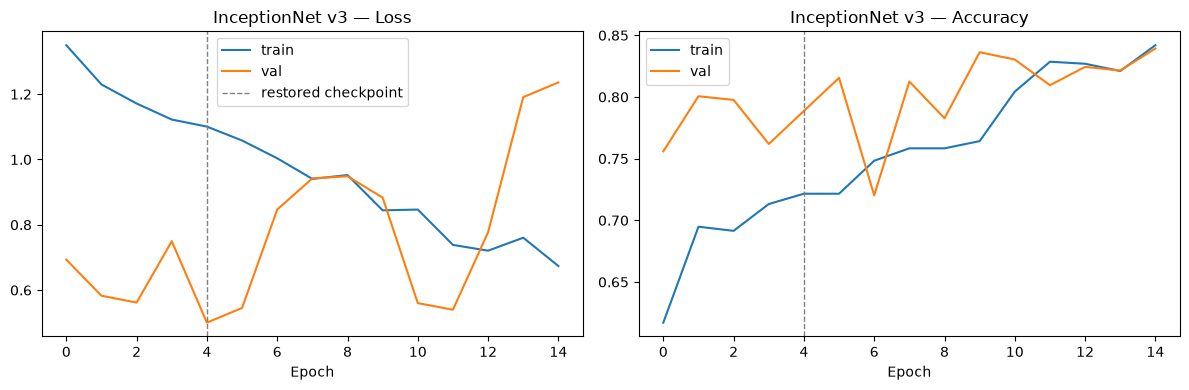

In [25]:
history_inception_v3 = train_model(
    model_inception_v3, train_loader_inception_v3, val_loader_inception_v3, optimizer_inception_v3, scheduler_inception_v3,
    criterion_inception_v3, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps_inception_v3,
)
plot_training_curves(history_inception_v3, "InceptionNet v3")


## Evaluate on the test set

Confusion matrix, per-class precision/recall/F1, and one-vs-rest ROC/AUC
curves — using the restored best checkpoint.

[InceptionNet v3] Test accuracy: 0.788


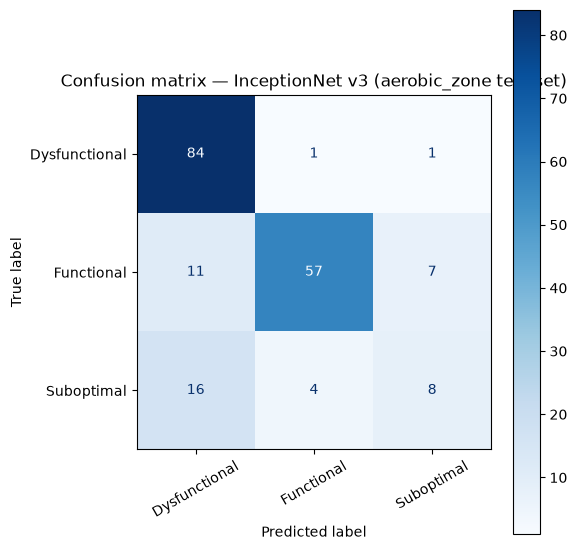

               precision    recall  f1-score   support

Dysfunctional      0.757     0.977     0.853        86
   Functional      0.919     0.760     0.832        75
   Suboptimal      0.500     0.286     0.364        28

     accuracy                          0.788       189
    macro avg      0.725     0.674     0.683       189
 weighted avg      0.783     0.788     0.772       189



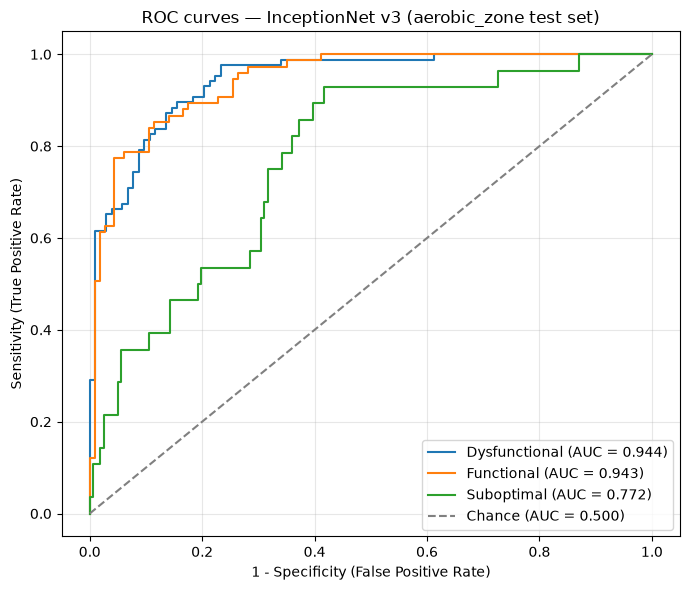

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.944
  Functional     : 0.943
  Suboptimal     : 0.772

Mean AUC: 0.886


(np.float64(0.7883597883597884),
 {'Dysfunctional': 0.9440054188304358,
  'Functional': 0.9429239766081872,
  'Suboptimal': 0.7715173025732033})

In [26]:
evaluate_and_record(
    model_inception_v3, test_loader_inception_v3, "InceptionNet v3", history_inception_v3,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)


### Free GPU memory before the next model

Same reasoning as after ResNet-18 — `optimizer_inception_v3` and `scheduler_inception_v3`
hold GPU-resident state that would otherwise accumulate across every
remaining section.

In [27]:
free_gpu("optimizer_inception_v3", "scheduler_inception_v3", "criterion_inception_v3", scope=globals())


[GPU memory — after cleanup] allocated: 0.07 GB | reserved: 0.07 GB


# 10. Model comparison

A quick side-by-side of test accuracy and mean AUC across all four
backbones, now that they've all been trained and evaluated the same way.

,test_accuracy,mean_auc,hidden_layers,neurons,img_size
model,,,,,
ResNet-18,0.756614,0.904812,0,NaN,"(112, 224)"
ResNet-50,0.687831,0.860353,3,1024.0,"(112, 224)"
DenseNet-121,0.746032,0.902814,3,2048.0,"(112, 224)"
InceptionNet v3,0.788360,0.886149,3,2048.0,"(299, 299)"


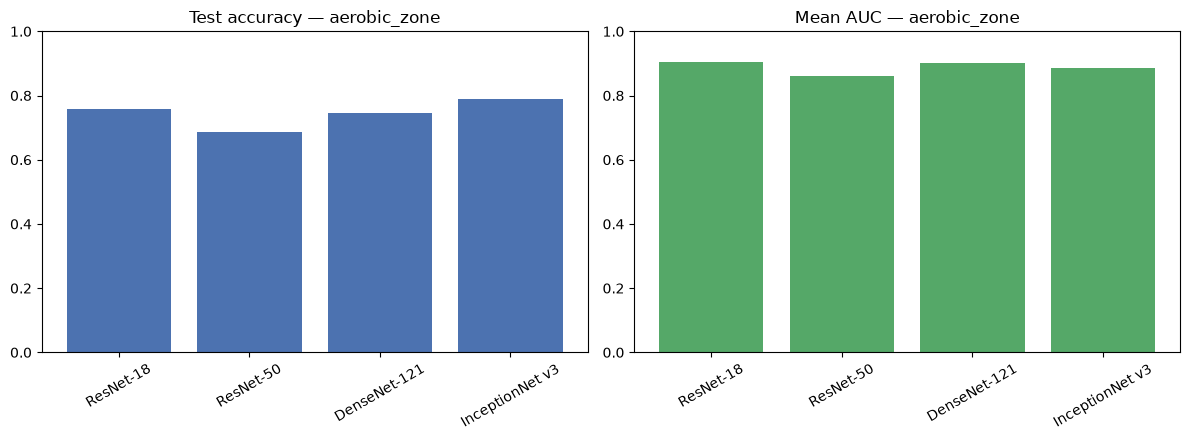

In [28]:
comparison = pd.DataFrame([
    {
        "model": name,
        "test_accuracy": r["test_acc"],
        "mean_auc": r["mean_auc"],
        "hidden_layers": r["hidden_layers"],
        "neurons": r["neurons"],
        "img_size": r["img_size"],
    }
    for name, r in results.items()
]).set_index("model")

display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(comparison.index, comparison["test_accuracy"], color="#4C72B0")
axes[0].set_title(f"Test accuracy — {COMPONENT}")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(comparison.index, comparison["mean_auc"], color="#55A868")
axes[1].set_title(f"Mean AUC — {COMPONENT}")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


# 11. Save the trained models

In [29]:
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

for key, name in [
    ("ResNet-18", "resnet18"),
    ("ResNet-50", "resnet50"),
    ("DenseNet-121", "densenet121"),
    ("InceptionNet v3", "inception_v3"),
]:
    r = results[key]
    save_path = MODEL_SAVE_PATH.parent / f"{COMPONENT}_{name}_cnn.pt"
    torch.save({
        "model_state_dict": r["model"].state_dict(),
        "class_names": class_names,
        "img_target_size": r["img_size"],
        "component": COMPONENT,
        "hidden_layers": r["hidden_layers"],
        "neurons": r["neurons"],
        "test_accuracy": r["test_acc"],
        "mean_auc": r["mean_auc"],
    }, save_path)
    print(f"Saved {key} to {save_path}")


Saved ResNet-18 to ../models/aerobic_zone_resnet18_cnn.pt
Saved ResNet-50 to ../models/aerobic_zone_resnet50_cnn.pt
Saved DenseNet-121 to ../models/aerobic_zone_densenet121_cnn.pt
Saved InceptionNet v3 to ../models/aerobic_zone_inception_v3_cnn.pt
